In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error , r2_score

# ── 1. Generate synthetic data with a quadratic relationship ──────────────────
X, y_linear = make_regression(n_samples=100, n_features=1, noise=15, random_state=42)
# make_regression gives us a linear y. We override it with a quadratic relationship.
y = X.squeeze() ** 2 + 0.5 * y_linear   # quadratic base + linear noise contribution

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
# Let us fit the linear Model first and get the idea of coefs and intercept

lr = LinearRegression()

model_lr = lr.fit(X_train , y_train)
y_pred = model_lr.predict(X_test)

#------Model Evaluation--------------

print(f"Coefs -> {model_lr.coef_}")
print(f"Intercept -> {model_lr.intercept_}")
print(f"MAE = {mean_squared_error(y_test , y_pred)}")
print(f"R2 Score = {r2_score(y_test , y_pred)}")


Coefs -> [22.35142975]
Intercept -> 0.857761382150509
MAE = 62.220006727348526
R2 Score = 0.864873140685293


In [8]:
# Let us use Ridge Regression Model Now and see the changes in the fitting
coefs = []
for i in [0, 0.1 , 0.5 , 1 , 10 , 100]:
    rm = Ridge(alpha = i , solver = "cholesky")

    model_rm = rm.fit(X_train , y_train)

    y_pred_rm = model_rm.predict(X_test)
    coefs.append(model_rm.coef_)

    #------Model Evaluation--------------
    print(f"\tRidge Model Alpha = {i}\n")
    print(f"Coefs -> {model_rm.coef_}")
    print(f"Intercept -> {model_rm.intercept_}")
    print(f"MAE = {mean_squared_error(y_test , y_pred)}")
    print(f"R2 Score = {r2_score(y_test , y_pred)}")

	Ridge Model Alpha = 0

Coefs -> [22.35142975]
Intercept -> 0.8577613821505099
MAE = 62.220006727348526
R2 Score = 0.864873140685293
	Ridge Model Alpha = 0.1

Coefs -> [22.31731774]
Intercept -> 0.8533727205071555
MAE = 62.220006727348526
R2 Score = 0.864873140685293
	Ridge Model Alpha = 0.5

Coefs -> [22.1819046]
Intercept -> 0.8359512177292499
MAE = 62.220006727348526
R2 Score = 0.864873140685293
	Ridge Model Alpha = 1

Coefs -> [22.01493162]
Intercept -> 0.8144694027525787
MAE = 62.220006727348526
R2 Score = 0.864873140685293
	Ridge Model Alpha = 10

Coefs -> [19.38797817]
Intercept -> 0.476500170073459
MAE = 62.220006727348526
R2 Score = 0.864873140685293
	Ridge Model Alpha = 100

Coefs -> [8.83979978]
Intercept -> -0.8805698412202723
MAE = 62.220006727348526
R2 Score = 0.864873140685293


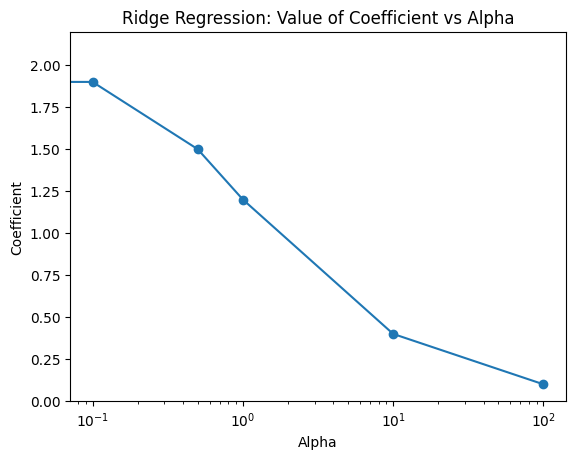

In [15]:
import matplotlib.pyplot as plt

plt.plot([0, 0.1 , 0.5 , 1 , 10 , 100], coefs, marker='o')
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient')
plt.title('Ridge Regression: Value of Coefficient vs Alpha')
plt.show()

In [ ]:
# Let us make a polynomial function of Degree = 9
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd
model = 

**A Pipeline chains multiple steps (like PolynomialFeatures → StandardScaler → Ridge) into one object. When you call pipe.fit(), it runs fit_transform on all steps except the last, and fit on the last. When you call pipe.predict(), it runs transform through all preprocessing steps, then predict at the end. This prevents data leakage and makes the code clean.**

Model                             Train MSE     Test MSE        Gap
--------------------------------------------------------------------
Linear (degree=1)                     41.77        62.22      20.45
Poly degree=9 (overfit)               40.07        61.28      21.22
Poly degree=9 + Ridge                 48.28        75.40      27.12


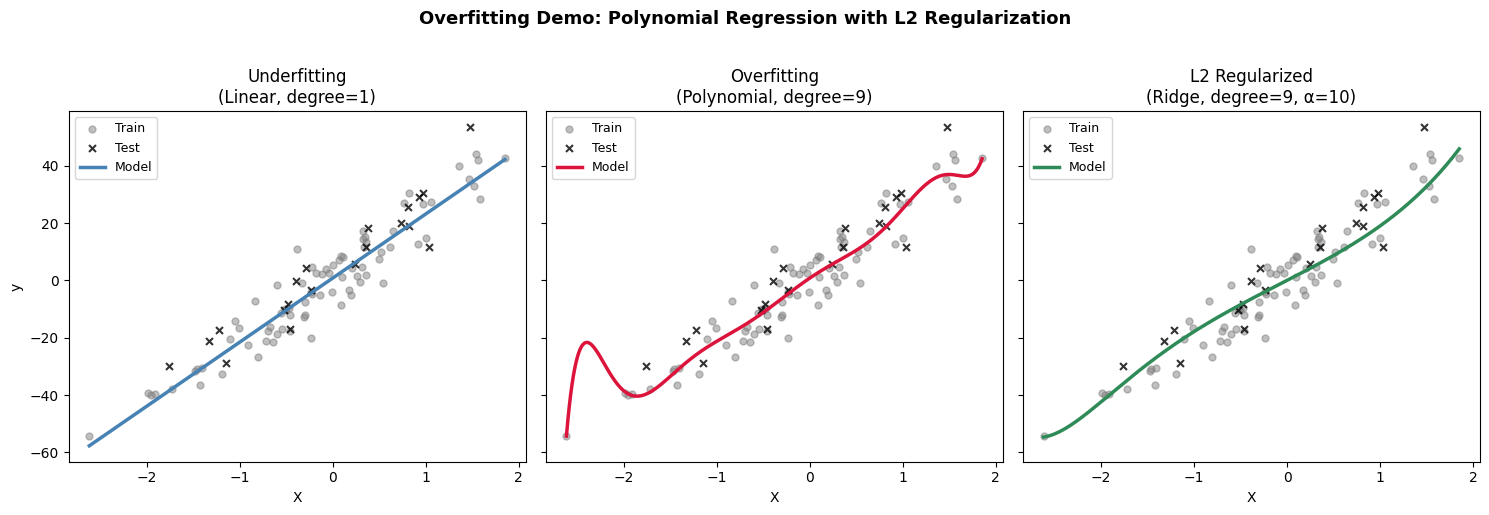

In [ ]:
# ── 1. Build three pipelines ──────────────────────────────────────────────────
def make_pipeline(degree, alpha=0.0): 
    steps = [
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)), # Pipeline performs this First
        # include_bias = False means we not add constant column in the start, we can if we want to work with Gradient Descent Algo

        ('scaler', StandardScaler()),      # second this will be applied
    ]
    if alpha > 0:
        steps.append(('model', Ridge(alpha=alpha)))
    else:
        steps.append(('model', LinearRegression()))
    return Pipeline(steps)                # Pipeline chains many things in one (like PolynomialFeatures → StandardScaler → Ridge) into one object. 
 
pipe_linear   = make_pipeline(degree=1)        # underfitting
pipe_overfit  = make_pipeline(degree=9)        # overfitting
pipe_ridge    = make_pipeline(degree=9, alpha=10)  # L2 regularized

# ── 3. Fit all three ──────────────────────────────────────────────────────────
for pipe in [pipe_linear, pipe_overfit, pipe_ridge]:
    pipe.fit(X_train, y_train)  # This fits and transform the data now one by one 

# ── 4. Evaluate: train vs test MSE ───────────────────────────────────────────
models = {
    "Linear (degree=1)":        pipe_linear,
    "Poly degree=9 (overfit)":  pipe_overfit,
    "Poly degree=9 + Ridge":    pipe_ridge,
}

print(f"{'Model':<30} {'Train MSE':>12} {'Test MSE':>12} {'Gap':>10}")
print("-" * 68)
for name, pipe in models.items():
    train_mse = mean_squared_error(y_train, pipe.predict(X_train))
    test_mse  = mean_squared_error(y_test,  pipe.predict(X_test))
    gap       = test_mse - train_mse
    print(f"{name:<30} {train_mse:>12.2f} {test_mse:>12.2f} {gap:>10.2f}")

# ── 5. Plot ───────────────────────────────────────────────────────────────────
X_plot = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
titles = ["Underfitting\n(Linear, degree=1)",
          "Overfitting\n(Polynomial, degree=9)",
          "L2 Regularized\n(Ridge, degree=9, α=10)"]
pipes  = [pipe_linear, pipe_overfit, pipe_ridge]
colors = ["steelblue", "crimson", "seagreen"]

for ax, title, pipe, color in zip(axes, titles, pipes, colors):
    ax.scatter(X_train, y_train, alpha=0.5, s=25, color="gray",  label="Train")
    ax.scatter(X_test,  y_test,  alpha=0.8, s=25, color="black", label="Test", marker="x")
    ax.plot(X_plot, pipe.predict(X_plot), color=color, linewidth=2.5, label="Model")
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("X")
    ax.legend(fontsize=9)

axes[0].set_ylabel("y")
plt.suptitle("Overfitting Demo: Polynomial Regression with L2 Regularization", 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("overfitting_demo.png", dpi=130, bbox_inches="tight")
plt.show()